In [1]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers import RiedGuachalla2025

In [2]:
importlib.reload(RiedGuachalla2025)

RiedGuachalla2025.Table2().df

,Bin,zmean,zmed,Mstar/1e11Msun,N,chi2null,SN,kSZ_kSZfid,sigmakSZ_sigmakSZfid,Unnamed: 9,logMstarMin,logMstarMax,zspecMin,zspecMax
0,Full sample,0.74,0.75,2.2,825283,105.9,9.8,1.00,0.00,NaN,NaN,NaN,0.50,1.10
1,z1,0.51,0.51,2.4,195877,36.5,5.6,1.12,0.21,NaN,NaN,NaN,0.40,0.60
2,z2,0.71,0.71,2.3,297440,46.6,5.1,0.99,0.16,NaN,NaN,NaN,0.60,0.80
3,z3,0.87,0.87,2.0,235620,42.8,5.8,1.03,0.18,NaN,NaN,NaN,0.80,0.95
4,z4,1.01,1.01,2.1,96346,9.6,2.3,0.69,0.29,NaN,NaN,NaN,0.95,1.10
5,mass1,0.76,0.79,1.2,244932,20.6,4.3,0.77,0.17,NaN,10.5,11.2,NaN,NaN
6,mass2,0.75,0.76,2.0,320914,44.4,6.0,0.97,0.16,NaN,11.2,11.4,NaN,NaN
7,mass3,0.71,0.70,3.0,194037,26.7,4.5,0.98,0.20,NaN,11.4,11.6,NaN,NaN
8,mass4,0.69,0.67,5.1,53997,47.7,6.2,2.47,0.40,NaN,11.6,12.5,NaN,NaN
9,Mag-g1,0.80,0.82,2.9,299592,55.2,7.1,1.19,0.16,NaN,NaN,NaN,NaN,NaN


z_1 Ngal=195877 from paper, sum of N_z 195951, int of dNdz 191932
z_2 Ngal=297440 from paper, sum of N_z 297541, int of dNdz 290929
z_3 Ngal=235620 from paper, sum of N_z 235710, int of dNdz 231089
z_4 Ngal=96346 from paper, sum of N_z 96378, int of dNdz 94138


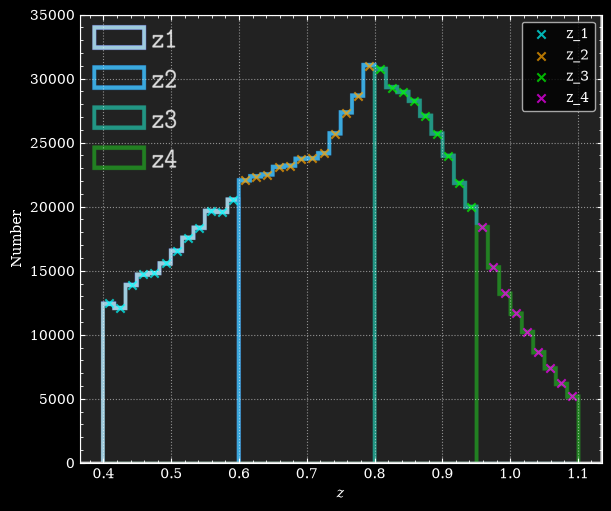

In [32]:
importlib.reload(RiedGuachalla2025)

fig, ax = RiedGuachalla2025.Fig2().full()

bins = ['z_1', 'z_2', 'z_3', 'z_4']
colors = ['cyan', 'orange', 'lime', 'magenta']
zNums = [13, 13, 10, 10]
for bin, color, zNum in zip(bins, colors, zNums):
    RG25 = RiedGuachalla2025.TargetData(bin=bin)
    z, N_z = RG25.N_z(zNum=zNum)
    ax.scatter(z, N_z, alpha=0.7, marker='x', c=color, label=f'{bin}')
    
    z, dNdz = RG25.dNdz(zNum=50)
    print(f"{RG25.bin} Ngal={RG25.NGal} from paper, sum of N_z {N_z.sum():.0f}, int of dNdz {np.trapezoid(dNdz, z):.0f}")

ax.legend()
plt.show()

mass_1 Ngal=244932, sum of N_logMs 244932, int of dNdlogMs 240130
mass_2 Ngal=320914, sum of N_logMs 320914, int of dNdlogMs 317934
mass_3 Ngal=194037, sum of N_logMs 194037, int of dNdlogMs 191937
mass_4 Ngal=53997, sum of N_logMs 53997, int of dNdlogMs 51834


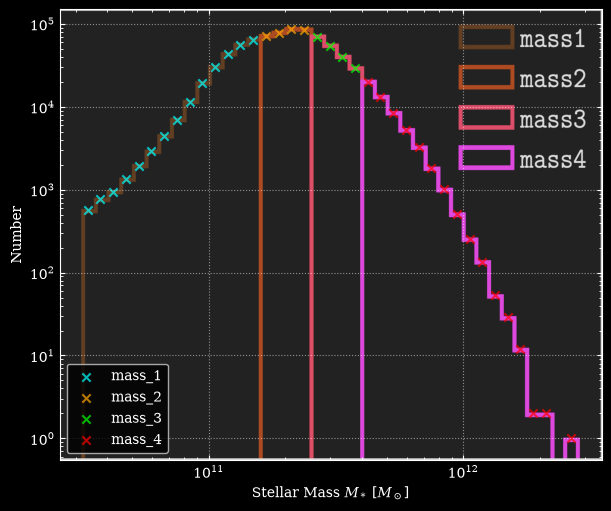

In [31]:
importlib.reload(RiedGuachalla2025)

fig, ax = RiedGuachalla2025.Fig3().full()


bins = ['mass_1', 'mass_2', 'mass_3', 'mass_4']
colors = ['cyan', 'orange', 'lime', 'red']
logMsNums = [15, 5, 5, 19]
for bin, color, logMsNum in zip(bins, colors, logMsNums):
    RG25 = RiedGuachalla2025.TargetData(bin=bin)
    logMs, N_logMs = RG25.N_logMs(logMsNum=logMsNum)
    ax.scatter(10**logMs, N_logMs, alpha=0.7, marker='x', c=color, label=f'{RG25.bin}')
    
    logMs, dNdlogMs = RG25.dNdlogMs(logMsNum=100)
    print(f'{RG25.bin} Ngal={RG25.NGal}, sum of N_logMs {N_logMs.sum():.0f}, int of dNdlogMs {np.trapezoid(dNdlogMs, logMs):.0f}')

ax.legend(loc='lower left')
plt.show()

AttributeError: module 'Models.Papers.RiedGuachalla2025' has no attribute 'Measurements'

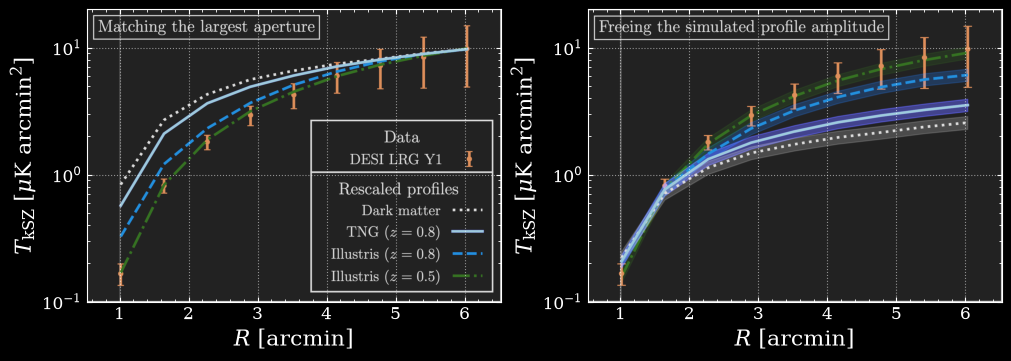

In [5]:
importlib.reload(RiedGuachalla2025)
fig, axs = RiedGuachalla2025.Fig8().full()

RG25 = RiedGuachalla2025.Measurements({'bin':'all'})

axs[0].errorbar(RG25.R, RG25.TkSZ_data, RG25.TkSZ_err, markersize=10, capsize=5, marker='x', alpha=0.7, ls='', label=f'all', c='magenta')

for ax in axs: ax.legend()
plt.show()

In [ ]:
importlib.reload(RiedGuachalla2025)
fig, ax = RiedGuachalla2025.Fig11().full()

bins = ['z_1', 'z_2', 'z_3', 'z_4']
colors = [plt.colormaps['spring'](i) for i in np.linspace(0, 1, len(bins))]
for i, bin in enumerate(bins):
    RG25 = RiedGuachalla2025.Measurements({'bin':bin})
    ax.errorbar(RG25.R+np.int32(bin[-1])/30*u.arcmin, RG25.TkSZ_data, RG25.TkSZ_err, alpha=0.5, marker='x', c=colors[i], markersize=10, capsize=10, ls='', label=f'{bin}')

ax.legend()
plt.show()

In [ ]:
importlib.reload(RiedGuachalla2025)

fig, ax = RiedGuachalla2025.Fig12().full()

for bin in ['mass_1', 'mass_2', 'mass_3', 'mass_4']:
    RG25 = RiedGuachalla2025.Measurements({'bin':bin})
    ax.errorbar(RG25.R+np.int32(bin[-1])/30*u.arcmin, RG25.TkSZ_data, RG25.TkSZ_err, lw=0,alpha=0.9,marker='x', label=f'{bin}')

ax.legend()
plt.show()

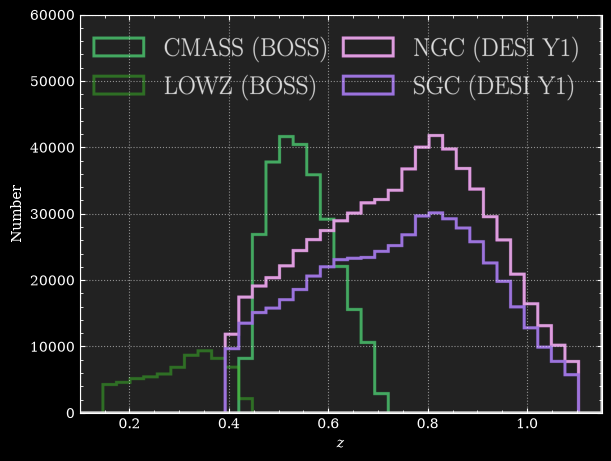

In [14]:
importlib.reload(RiedGuachalla2025)

fig, axs = RiedGuachalla2025.Fig20().full()